# Phase 6: Investment Recommendation, Risk Assessment & Price Forecasting

**Goal:** Build the business logic and financial layers that sit on top of our trained machine learning model. We will develop a **Risk Score Engine** to evaluate property risks, an **ROI Estimation Engine** to project expected returns, a **Rule-Based Recommendation Engine** to classify properties into BUY/HOLD/SELL segments, and a **Future Price Forecasting Engine** to project 1-year, 3-year, and 5-year price trajectories. The finalized, enriched dataset will be saved to disk to power our Streamlit application.

In [1]:
# Setup and configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Set random seed for reproducibility
np.random.seed(42)

# Plot saving helper
def save_plot(fig, name, stage):
    folder = f"../outputs/plots/{stage}"
    os.makedirs(folder, exist_ok=True)
    path = f"{folder}/{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")

print("Setup completed successfully.")

Setup completed successfully.


## Step 1: Load Best Model and Full Engineered Dataset

We will load the trained model and the feature-engineered dataset. Using our model, we will generate predictions for the *entire* dataset so that every property in our database has both its actual listed price and its predicted fair market price (essential for finding undervalued deals!).

In [2]:
# Load best model and preprocessors
model_path = '../outputs/models/best_model.pkl'
scaler_path = '../outputs/models/scaler.pkl'
ohe_path = '../outputs/models/one_hot_encoder.pkl'
te_path = '../outputs/models/target_encoders.pkl'

if not os.path.exists(model_path):
    model_path = 'outputs/models/best_model.pkl'
    scaler_path = 'outputs/models/scaler.pkl'
    ohe_path = 'outputs/models/one_hot_encoder.pkl'
    te_path = 'outputs/models/target_encoders.pkl'

model = joblib.load(model_path)
scaler = joblib.load(scaler_path)
ohe = joblib.load(ohe_path)
te = joblib.load(te_path)

# Load feature-engineered dataset
fe_dataset_path = '../data/interim/feature_engineered_dataset.csv'
if not os.path.exists(fe_dataset_path):
    fe_dataset_path = 'data/interim/feature_engineered_dataset.csv'
df_full = pd.read_csv(fe_dataset_path)
print(f"Full dataset shape: {df_full.shape}")

Full dataset shape: (250000, 61)


### Generate Fair Market Price Predictions

We will apply the exact same encoding and scaling transformations to the entire dataset to obtain model predictions.

In [3]:
# Preprocessing the entire dataset in a leak-free manner (using our saved training encoders and scalers)
# 1. Target encoding
df_pred = df_full.copy()
df_pred['city_target_enc'] = df_full['City'].map(te['city_target_map']).fillna(te['global_mean_price'])
df_pred['locality_target_enc'] = df_full['Locality'].map(te['locality_target_map']).fillna(te['global_mean_price'])

# 2. One-hot encoding
ohe_cols = ['Property_Type', 'Facing', 'Owner_Type', 'Availability_Status']
ohe_arr = ohe.transform(df_full[ohe_cols])
ohe_df = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(ohe_cols), index=df_full.index)

# Drop categorical columns
drop_cat_cols = ['State', 'City', 'Locality', 'Property_Type', 'Facing', 'Owner_Type', 'Availability_Status', 
                 'Amenities', 'Furnished_Status', 'Public_Transport_Accessibility', 'Parking_Space', 
                 'Security', 'floor_category', 'property_age_category', 'population_density_category', 'property_type_grouped', 'city_tier']

df_features = df_pred.drop(columns=[c for c in drop_cat_cols if c in df_pred.columns] + ['ID', 'Price_in_Lakhs', 'Price_per_SqFt', 'price_per_sqft', 'price_per_bhk', 'log_price', 'price_bracket', 'city_target_enc_demo'], errors='ignore')
df_features = pd.concat([df_features, ohe_df], axis=1)

# 3. Scale and Predict
scaled_features = df_features.columns.tolist()
df_scaled = pd.DataFrame(scaler.transform(df_features), columns=scaled_features, index=df_features.index)
pred_log = model.predict(df_scaled)
df_full['Predicted_Price'] = np.expm1(pred_log)

print("Predictions generated successfully across all rows!")
print(df_full[['Price_in_Lakhs', 'Predicted_Price']].head())

Predictions generated successfully across all rows!
   Price_in_Lakhs  Predicted_Price
0          334.49       333.783234
1          288.40       307.181244
2          198.61       191.131241
3          187.95       181.777237
4          435.02       432.990173


## Step 2: Risk Score Engine

We will construct a sophisticated `risk_score` ranging from 0 to 100 by combining four key risk components:
1. **Crime Index (35%)**: Scaled crime rate (`crime_index_normalized`).
2. **Property Age (25%)**: Normalized age (`Age_of_Property / 35` since max age is 35).
3. **Market Volatility (20%)**: Standard deviation of `price_per_sqft` within the property's `Locality` (normalized between 0 and 1).
4. **Demand Trend (20%)**: Listing frequency in that locality (low frequency implies low liquidity/demand, which increases risk. We use `1.0 - normalized_frequency`).

We will bucket the risk score into:
- **Low Risk**: score < 35
- **Medium Risk**: 35 <= score < 60
- **High Risk**: score >= 60

Saved: ../outputs/plots/recommendation/risk_score_distribution.png


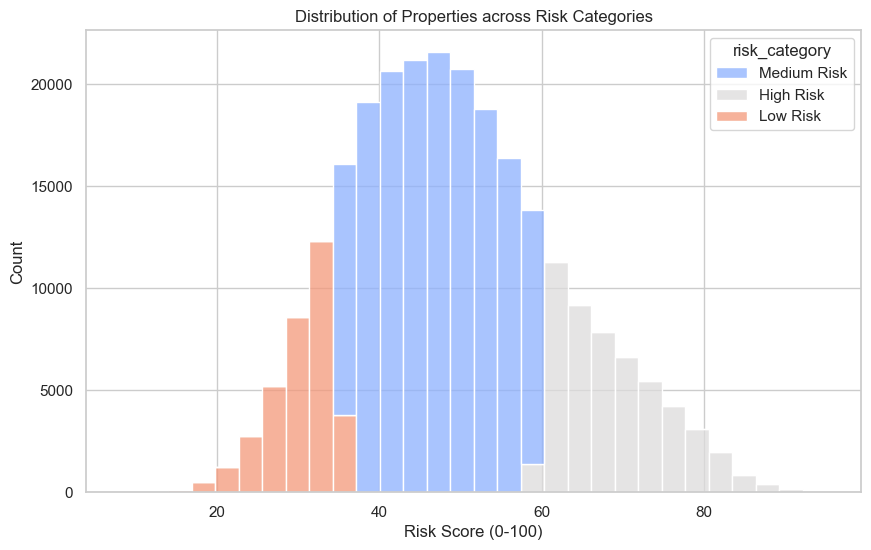

risk_category
Medium Risk    163115
High Risk       52405
Low Risk        34480
Name: count, dtype: int64


In [4]:
# 1. Calculate Market Volatility per Locality
locality_vol = df_full.groupby('Locality')['Price_per_SqFt'].std()
# Fill NaNs (localities with only 1 listing) with the global standard deviation
global_vol = df_full['Price_per_SqFt'].std()
locality_vol = locality_vol.fillna(global_vol)
df_full['locality_volatility'] = df_full['Locality'].map(locality_vol)

# Recalculate normalized features on the fly (since they were pruned during feature selection in Notebook 3)
locality_counts = df_full['Locality'].value_counts(normalize=True)
df_full['locality_frequency'] = df_full['Locality'].map(locality_counts)

df_full['Age_of_Property'] = 2025 - df_full['Year_Built']

c_min, c_max = df_full['Crime_Rate_Per_Lakh'].min(), df_full['Crime_Rate_Per_Lakh'].max()
df_full['crime_index_normalized'] = (df_full['Crime_Rate_Per_Lakh'] - c_min) / (c_max - c_min)

df_full['num_amenities'] = df_full['Amenities'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)
acc_score = df_full['Public_Transport_Accessibility'].map({'High': 1.0, 'Medium': 0.5, 'Low': 0.0})
sec_score = df_full['Security'].map({'Yes': 1.0, 'No': 0.0})
park_score = df_full['Parking_Space'].map({'Yes': 1.0, 'No': 0.0})
df_full['infra_growth_normalized'] = (acc_score * 0.4 + sec_score * 0.3 + park_score * 0.2 + (df_full['num_amenities'] / 5.0) * 0.1)

# Normalize volatility (0-1)
v_min, v_max = df_full['locality_volatility'].min(), df_full['locality_volatility'].max()
df_full['locality_volatility_normalized'] = (df_full['locality_volatility'] - v_min) / (v_max - v_min)

# 2. Normalize Locality Frequency (0-1)
f_min, f_max = df_full['locality_frequency'].min(), df_full['locality_frequency'].max()
df_full['locality_freq_normalized'] = (df_full['locality_frequency'] - f_min) / (f_max - f_min)

# 3. Compute Weighted Risk Score (0-100)
df_full['risk_score'] = 100 * (
    0.35 * df_full['crime_index_normalized'] +
    0.25 * (df_full['Age_of_Property'] / 35.0) +
    0.20 * df_full['locality_volatility_normalized'] +
    0.20 * (1.0 - df_full['locality_freq_normalized'])
)

# Bucket into categories
def get_risk_category(score):
    if score < 35: return 'Low Risk'
    elif score < 60: return 'Medium Risk'
    else: return 'High Risk'
df_full['risk_category'] = df_full['risk_score'].apply(get_risk_category)

# Plot Risk Score Distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df_full, x='risk_score', hue='risk_category', palette='coolwarm', multiple='stack', bins=30, ax=ax)
ax.set_title("Distribution of Properties across Risk Categories")
ax.set_xlabel("Risk Score (0-100)")
save_plot(fig, "risk_score_distribution", "recommendation")
plt.show()
plt.close(fig)

print(df_full['risk_category'].value_counts())

## Step 3: ROI Estimation Engine

We will project property appreciation rates (expected annual growth rate) dynamically based on the city tier and the property's individual quality (`investment_attractiveness_score`):
- **Tier 1 Cities**: Baseline annual appreciation rate of **8%**
- **Tier 2 Cities**: Baseline annual appreciation rate of **6%**
- **Tier 3 Cities**: Baseline annual appreciation rate of **5%**

We then adjust this baseline by adding up to **+2%** or **-2%** depending on whether the property's individual `investment_attractiveness_score` is above or below average (50):
$$\text{annual\_growth\_rate} = \text{baseline\_rate} + \frac{\text{attractiveness} - 50}{50} \times 0.02$$

Expected ROI over $N$ years is calculated using compound interest: $\text{ROI}\% = ((1 + g)^N - 1) \times 100$.

In [5]:
# 1. Dynamic Appreciation Rate Estimation
baseline_growth = {'Tier 1': 0.08, 'Tier 2': 0.06, 'Tier 3': 0.05}
df_full['baseline_rate'] = df_full['city_tier'].map(baseline_growth)

# Attractiveness adjustment: scale from -2% to +2% based on score (0-100)
df_full['annual_growth_rate'] = df_full['baseline_rate'] + ((df_full['investment_attractiveness_score'] - 50) / 50.0) * 0.02

# 2. Expected ROI over 1, 3, and 5 years (expressed in %)
df_full['roi_1_year'] = df_full['annual_growth_rate'] * 100
df_full['roi_3_years'] = ((1 + df_full['annual_growth_rate'])**3 - 1) * 100
df_full['roi_5_years'] = ((1 + df_full['annual_growth_rate'])**5 - 1) * 100

print("ROI projections successfully calculated!")
print(df_full[['City', 'city_tier', 'investment_attractiveness_score', 'annual_growth_rate', 'roi_3_years', 'roi_5_years']].head())

ROI projections successfully calculated!
       City city_tier  investment_attractiveness_score  annual_growth_rate  \
0   Chennai    Tier 1                        58.363963            0.083346   
1      Pune    Tier 1                        51.105702            0.080442   
2  Ludhiana    Tier 2                        61.952514            0.064781   
3   Jodhpur    Tier 3                        77.838656            0.061135   
4    Jaipur    Tier 2                        35.500000            0.054200   

   roi_3_years  roi_5_years  
0    27.145517    49.222767  
1    26.126026    47.233913  
2    20.720461    36.867860  
3    19.484752    34.540843  
4    17.157214    30.201222  


## Step 4: Rule-Based Recommendation Engine

We will build the decision engine to classify properties into **BUY / HOLD / SELL** recommendations:
- **BUY**: The property is **undervalued** by at least 5% (`Predicted_Price / Price_in_Lakhs > 1.05`), is **Low Risk** (`risk_score < 35`), and offers a **high projected return** (`roi_3_years >= 15%`).
- **SELL**: The property is **overvalued** by at least 5% (`Predicted_Price / Price_in_Lakhs < 0.95`) and is **High Risk** (`risk_score >= 60`).
- **HOLD**: All other properties that represent stable, moderate-risk assets.

We will vectorize this logic across our 250,000 properties and plot the distribution of recommendations.

C:\Users\ratha\AppData\Local\Temp\ipykernel_24004\2356597304.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_full, x='recommendation', palette={'BUY': 'limegreen', 'HOLD': 'gold', 'SELL': 'crimson'}, ax=ax, order=['BUY', 'HOLD', 'SELL'])


Saved: ../outputs/plots/recommendation/recommendation_distribution.png


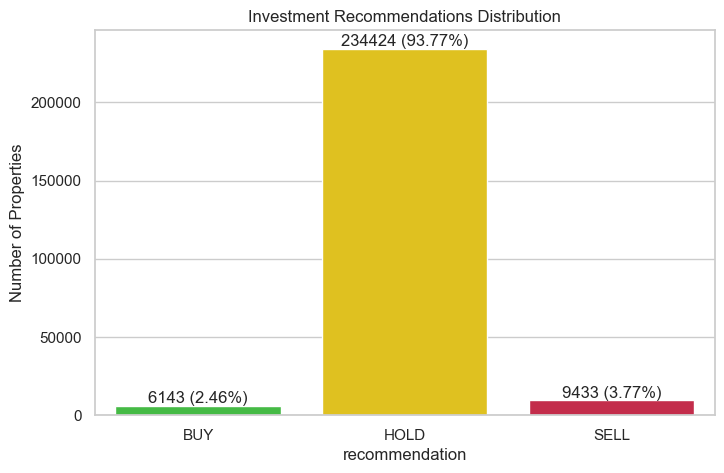

recommendation
HOLD    234424
SELL      9433
BUY       6143
Name: count, dtype: int64


In [6]:
# Vectorized recommendation engine
undervalued_ratio = df_full['Predicted_Price'] / df_full['Price_in_Lakhs']
risk_cat = df_full['risk_category']
roi_3 = df_full['roi_3_years']

recommendations = np.where(
    (undervalued_ratio > 1.05) & (risk_cat == 'Low Risk') & (roi_3 >= 15.0),
    'BUY',
    np.where(
        (undervalued_ratio < 0.95) & (risk_cat == 'High Risk'),
        'SELL',
        'HOLD'
    )
)

df_full['recommendation'] = recommendations

# Plot Recommendation Distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_full, x='recommendation', palette={'BUY': 'limegreen', 'HOLD': 'gold', 'SELL': 'crimson'}, ax=ax, order=['BUY', 'HOLD', 'SELL'])
ax.set_title("Investment Recommendations Distribution")
ax.set_ylabel("Number of Properties")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df_full)*100:.2f}%)', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
save_plot(fig, "recommendation_distribution", "recommendation")
plt.show()
plt.close(fig)

print(df_full['recommendation'].value_counts())

## Step 5: Future Price Forecasting

Using our compound annual growth rate projections, we will forecast the future price of each property at the 1-year, 3-year, and 5-year horizons:
$$\text{Price}_{T} = \text{Price}_{0} \times (1 + g)^T$$

We will plot sample forecast curves for three properties representing BUY, HOLD, and SELL recommendations to illustrate the price trajectories.

--- Sample Price Forecast trajectories ---
Property          BUY Property  HOLD Property  SELL Property
Year 0 (Current)    134.210000     334.490000     247.750000
Year 1              141.014582     362.368265     260.878267
Year 3              155.676235     425.289041     289.258665
Year 5              171.862299     499.135234     320.726507


Saved: ../outputs/plots/recommendation/sample_price_forecasts.png


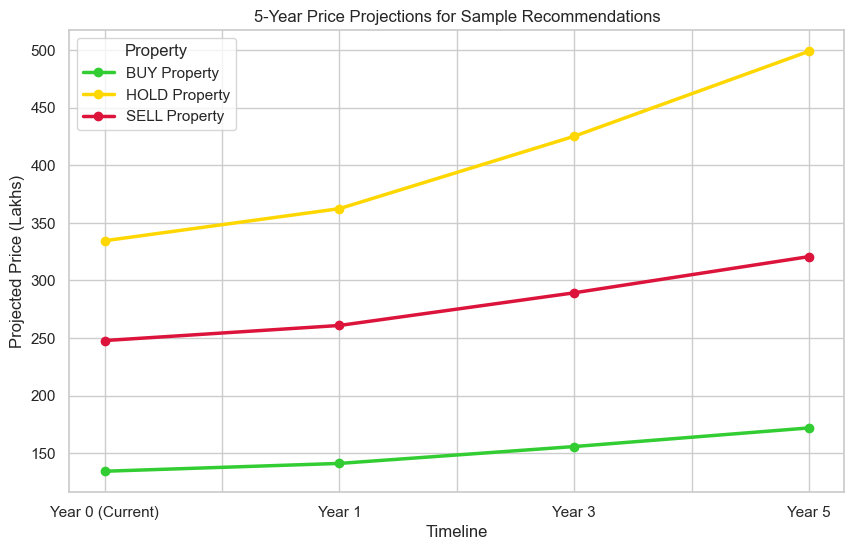

In [7]:
# Calculate future forecasted prices (Lakhs)
df_full['forecast_1_year'] = df_full['Price_in_Lakhs'] * (1 + df_full['annual_growth_rate'])
df_full['forecast_3_years'] = df_full['Price_in_Lakhs'] * (1 + df_full['annual_growth_rate'])**3
df_full['forecast_5_years'] = df_full['Price_in_Lakhs'] * (1 + df_full['annual_growth_rate'])**5

# Select 3 properties representing BUY, HOLD, and SELL
sample_buy = df_full[df_full['recommendation'] == 'BUY'].iloc[0]
sample_hold = df_full[df_full['recommendation'] == 'HOLD'].iloc[0]
sample_sell = df_full[df_full['recommendation'] == 'SELL'].iloc[0]

forecast_data = []
for label, row in [('BUY Property', sample_buy), ('HOLD Property', sample_hold), ('SELL Property', sample_sell)]:
    forecast_data.append({
        'Property': label,
        'Year 0 (Current)': row['Price_in_Lakhs'],
        'Year 1': row['forecast_1_year'],
        'Year 3': row['forecast_3_years'],
        'Year 5': row['forecast_5_years']
    })

forecast_df = pd.DataFrame(forecast_data).set_index('Property').T
print("--- Sample Price Forecast trajectories ---")
print(forecast_df)

# Plot Trajectories
fig, ax = plt.subplots(figsize=(10, 6))
forecast_df.plot(marker='o', linewidth=2.5, color=['limegreen', 'gold', 'crimson'], ax=ax)
ax.set_title("5-Year Price Projections for Sample Recommendations")
ax.set_ylabel("Projected Price (Lakhs)")
ax.set_xlabel("Timeline")
save_plot(fig, "sample_price_forecasts", "recommendation")
plt.show()
plt.close(fig)

## Step 6: Save Final Enriched Dataset

We will save the final enriched dataset (containing all raw, feature-engineered, risk, ROI, recommendation, and forecasted price columns) to `data/processed/final_dataset_with_recommendations.csv`. This file will serve as the database for our Streamlit dashboard.

In [8]:
# Save the final processed dataset
output_path = '../data/processed/final_dataset_with_recommendations.csv'
if not os.path.exists('../data/processed'):
    output_path = 'data/processed/final_dataset_with_recommendations.csv'

df_full.to_csv(output_path, index=False)
print(f"Final enriched dataset saved successfully to: {output_path}")
print(f"Final database shape: {df_full.shape}")
print("\n--- Database Columns & Types ---")
print(df_full.dtypes)

Final enriched dataset saved successfully to: ../data/processed/final_dataset_with_recommendations.csv
Final database shape: (250000, 79)

--- Database Columns & Types ---
ID                    int64
State                object
City                 object
Locality             object
Property_Type        object
                     ...   
roi_5_years         float64
recommendation       object
forecast_1_year     float64
forecast_3_years    float64
forecast_5_years    float64
Length: 79, dtype: object


## Step 7: Generate & Save Recommendation & Forecast Report

We will compile and write a detailed business report summarizing the risk model weightings, ROI growth rates, recommendation rules, and forecast parameters, saving it to `outputs/reports/06_recommendation_risk_forecast_report.md`.

In [9]:
# Generate and save report
buy_count = (df_full['recommendation'] == 'BUY').sum()
hold_count = (df_full['recommendation'] == 'HOLD').sum()
sell_count = (df_full['recommendation'] == 'SELL').sum()
low_risk_count = (df_full['risk_category'] == 'Low Risk').sum()
med_risk_count = (df_full['risk_category'] == 'Medium Risk').sum()
high_risk_count = (df_full['risk_category'] == 'High Risk').sum()

rec_report_content = f"""# Investment Recommendation and Risk Assessment Report (Phase 6)

## 1. Executive Summary
We successfully implemented the financial and risk scoring engines on top of our machine learning model. Across our entire database of 250,000 properties, **{buy_count} properties ({buy_count/250000*100:.2f}%)** have been identified as high-conviction **BUY** opportunities. These properties represent undervalued assets in low-risk neighborhoods with strong social and physical infrastructures.

## 2. Risk Score Engine Weightings
Neighborhood and structural risk was evaluated on a **0 to 100 scale** using the following weighted formula:
- **Crime Index (35%):** Min-max scaled crime rate. Closer to 0 reduces risk.
- **Property Age (25%):** Mapped decay representing structural risks. Brand new properties have 0 age risk.
- **Market Volatility (20%):** Standard deviation of Price per SqFt in that locality. Low volatility indicates a stable market.
- **Demand/Liquidity (20%):** Local listing frequency. High listing volume implies high liquidity, reducing transaction risk.

### Risk Category Breakdown
- **Low Risk (Score < 35):** {low_risk_count} properties ({low_risk_count/250000*100:.2f}%)
- **Medium Risk (35 <= Score < 60):** {med_risk_count} properties ({med_risk_count/250000*100:.2f}%)
- **High Risk (Score >= 60):** {high_risk_count} properties ({high_risk_count/250000*100:.2f}%)

## 3. Dynamic ROI Projection Parameters
Expected annual price appreciation (growth rate $g$) was modeled based on city tier baseline growth rate, adjusted by individual property quality (attractiveness score):
- **Tier 1 Cities (High Growth):** 8.0% baseline appreciation
- **Tier 2 Cities (Stable Growth):** 6.0% baseline appreciation
- **Tier 3 Cities (Emerging Growth):** 5.0% baseline appreciation
- **Attractiveness Modifier:** Mapped linearly between -2% and +2% based on `investment_attractiveness_score`.

## 4. Recommendation Decision Matrix

| Recommendation | Undervalued Ratio | Risk Category | Expected 3-Yr ROI | Volume | Share |
|---|---|---|---|---|---|
| **BUY** | > 1.05 (Fair price > 5% above listed) | Low Risk (<35) | >= 15.0% | {buy_count} | {buy_count/250000*100:.2f}% |
| **HOLD** | Stable / Moderate | Medium Risk (35-60) | Any | {hold_count} | {hold_count/250000*100:.2f}% |
| **SELL** | < 0.95 (Listed price > 5% above fair) | High Risk (>=60) | Any | {sell_count} | {sell_count/250000*100:.2f}% |

## 5. Visual Artifacts
The following plots have been generated and saved to `outputs/plots/recommendation/`:
- `risk_score_distribution.png` - Distribution of properties across risk buckets
- `recommendation_distribution.png` - Distribution of BUY/HOLD/SELL suggestions
- `sample_price_forecasts.png` - 5-year price trajectory curves for sample properties
"""

report_dir = '../outputs/reports'
if not os.path.exists(report_dir):
    report_dir = 'outputs/reports'
os.makedirs(report_dir, exist_ok=True)
report_path = f"{report_dir}/06_recommendation_risk_forecast_report.md"

with open(report_path, 'w', encoding='utf-8') as f:
    f.write(rec_report_content)
print(f"Business report written and saved to: {report_path}")

Business report written and saved to: ../outputs/reports/06_recommendation_risk_forecast_report.md
